# Módulo 4 - PCA, clustering exploratorio y cierre del flujo ML

## Banco Mundial - INEC - USFQ

Este módulo pasa de modelos supervisados a exploración no supervisada. Usaremos `roads_canton_mean.csv` para:

- Reducir la dimensión de indicadores de movilidad por cantón con PCA.
- Explorar segmentaciones de cantones con k-means.
- Interpretar clusters usando provincia, volumen de viajes y patrones temporales de movilidad.
- Cerrar el flujo de trabajo completo de machine learning: datos, preparación, modelado, validación, interpretación y comunicación.

Al final, el estudiante debería poder:

- Preparar datos para métodos no supervisados.
- Interpretar varianza explicada y cargas principales de un PCA.
- Usar PCA como herramienta de visualización.
- Aplicar k-means y evaluar distintos valores de `k`.
- Elegir el número de clusters con métricas exploratorias de `tidyclust`.
- Conectar clustering con el flujo completo de ML.

## 0. Paquetes, semilla y salidas

Usaremos funciones base de R para PCA (`prcomp`) y `tidyclust` para ajustar y evaluar k-means dentro del ecosistema `tidymodels`.

In [19]:
paquetes <- c("tidymodels", "tidyverse", "tidyclust", "broom")

paquetes_faltantes <- paquetes[!vapply(paquetes, requireNamespace, logical(1), quietly = TRUE)]
paquetes_faltantes

# Si aparece algún paquete faltante, descomentar y ejecutar:
# install.packages(paquetes_faltantes)

suppressPackageStartupMessages({
  library(tidymodels)
  library(tidyverse)
  library(tidyclust)
  library(broom)
  library(readxl)
})

tidymodels_prefer()
theme_set(theme_minimal(base_size = 12))

semilla_global <- 123
set.seed(semilla_global)

output_dir <- file.path("output", "modulo4")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

character(0)

## 1. Datos de movilidad por cantón

Usamos `roads_canton_mean.csv`, que resume viajes promedio por cantón, provincia, día de la semana y franja horaria. En clustering no hay una variable objetivo: variables como `canton`, `name_es`, `provincia`, `viajes` y `viajeros` se reservan para interpretar los grupos después.

In [20]:
roads <- read_csv("data/roads_canton_mean.csv", show_col_types = FALSE) %>%
  mutate(
    provincia = as.factor(provincia),
    prop_weekend = weekend_all / (weekday_all + weekend_all),
    prop_night = (weekday_night + weekend_night) / (weekday_all + weekend_all)
  )

glimpse(roads)

roads %>%
  summarise(
    cantones = n(),
    provincias = n_distinct(provincia),
    viajes_promedio = mean(viajes, na.rm = TRUE),
    viajeros_promedio = mean(viajeros, na.rm = TRUE)
  )

Rows: 209
Columns: 24
$ canton            <dbl> 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 11…
$ name_es           <chr> "CUENCA", "GIRÓN", "GUALACEO", "NABÓN", "PAUTE", "PU…
$ provincia         <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2…
$ viajes            <dbl> 17249.47830, 14927.52800, 4129.53796, 16034.73776, 9…
$ viajeros          <dbl> 16919.90105, 14861.52510, 4035.98896, 15944.00311, 8…
$ monday            <dbl> 12807.25090, 8306.06637, 3059.18196, 8508.35695, 650…
$ tuesday           <dbl> 13120.11364, 7670.37905, 3139.27320, 7893.80396, 638…
$ wednesday         <dbl> 13049.4077, 8117.7879, 3222.4963, 8703.8172, 6770.33…
$ thursday          <dbl> 14024.44212, 8683.05923, 3368.50189, 8911.90983, 706…
$ friday            <dbl> 15091.5406, 10667.8545, 3954.4897, 11001.5895, 8650.…
$ saturday          <dbl> 14922.60671, 11677.14181, 3902.37487, 11692.65186, 8…
$ sunday            <dbl> 13258.42555, 13274.71616, 4856.05322, 12145.75694, 1…
$ weekday_all     

cantones,provincias,viajes_promedio,viajeros_promedio
<int>,<int>,<dbl>,<dbl>
209,24,22418.77,22110.46


## 2. Matriz de análisis no supervisado

Para PCA y k-means necesitamos una matriz numérica comparable. Por eso usamos una receta que:

- imputa valores faltantes,
- elimina variables sin varianza,
- normaliza variables numéricas.

No incluimos identificadores ni totales generales en la matriz de clustering, porque queremos que los clusters se basen en el patrón temporal de movilidad.

In [21]:
receta_unsup <- recipe(
  ~ monday + tuesday + wednesday + thursday + friday + saturday + sunday +
    weekday_morning + weekday_afternoon + weekday_evening + weekday_night +
    weekend_morning + weekend_afternoon + weekend_evening + weekend_night +
    prop_weekend + prop_night,
  data = roads
) %>%
  step_impute_mean(all_numeric_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

prep_unsup <- prep(receta_unsup)

x_roads <- bake(prep_unsup, new_data = roads) %>%
  as_tibble()

metadata_roads <- roads %>%
  select(canton, name_es, provincia, viajes, viajeros, weekday_all, weekend_all, prop_weekend, prop_night)

list(
  filas = nrow(x_roads),
  columnas = ncol(x_roads)
)

$filas
[1] 209

$columnas
[1] 17

## 3. PCA exploratorio

PCA crea nuevas variables llamadas componentes principales. Cada componente resume una combinación lineal de las variables originales. La primera componente explica la mayor varianza posible, la segunda explica la mayor varianza restante, y así sucesivamente.

Siguiendo el estilo de `tidymodels`, usaremos `broom::tidy()` para extraer varianza explicada, scores y cargas desde el objeto `prcomp()`.

In [22]:
pca_roads <- prcomp(x_roads, center = FALSE, scale. = FALSE)

varianza_pca <- tidy(pca_roads, matrix = "eigenvalues") %>%
  transmute(
    componente = paste0("PC", PC),
    num_componente = PC,
    desviacion_estandar = std.dev,
    varianza = std.dev^2,
    prop_varianza = percent,
    prop_acumulada = cumulative
) %>%
  mutate(across(c(prop_varianza, prop_acumulada), as.numeric))

write_csv(varianza_pca, file.path(output_dir, "varianza_pca_roads.csv"))

varianza_pca %>%
  slice(1:10)

componente,num_componente,desviacion_estandar,varianza,prop_varianza,prop_acumulada
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PC1,1,3.85110186,14.830985561,0.87241,0.87241
PC2,2,1.05218549,1.107094305,0.06512,0.93753
PC3,3,0.92564853,0.856825206,0.05040,0.98794
PC4,4,0.32391425,0.104920439,0.00617,0.99411
PC5,5,0.23924585,0.057238577,0.00337,0.99747
PC6,6,0.12655365,0.016015826,0.00094,0.99842
PC7,7,0.11140512,0.012411101,0.00073,0.99915
PC8,8,0.05903025,0.003484571,0.00020,0.99935
PC9,9,0.05537358,0.003066233,0.00018,0.99953


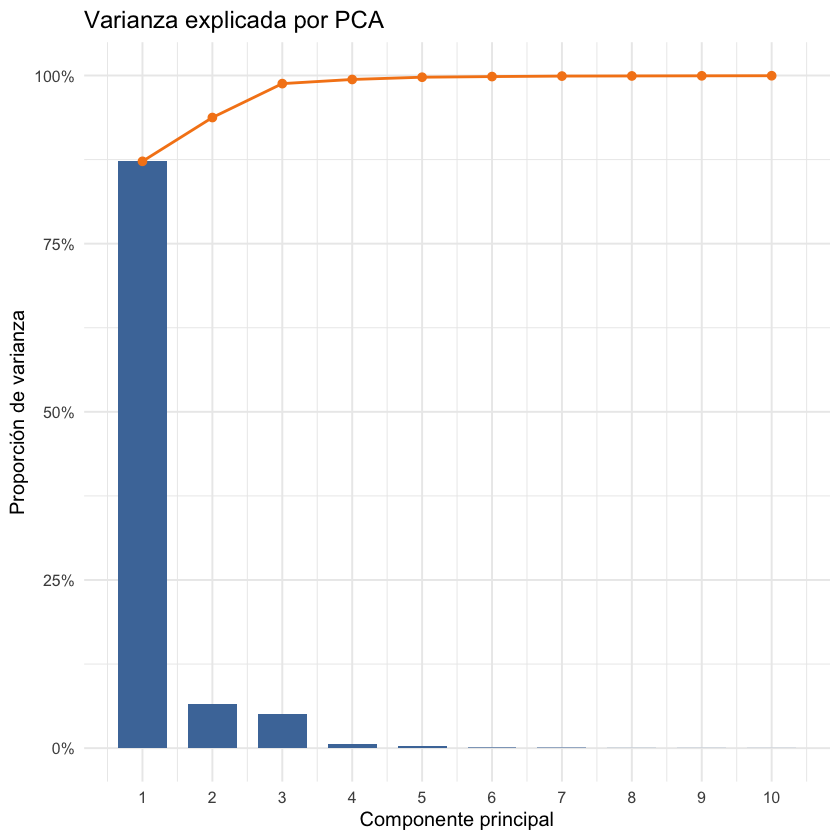

In [23]:
varianza_pca %>%
  slice(1:10) %>%
  ggplot(aes(x = num_componente, y = prop_varianza)) +
  geom_col(fill = "#4C78A8", width = 0.7) +
  geom_line(aes(y = prop_acumulada), color = "#F58518", linewidth = 0.8) +
  geom_point(aes(y = prop_acumulada), color = "#F58518", size = 2) +
  scale_x_continuous(breaks = 1:10) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    x = "Componente principal",
    y = "Proporción de varianza",
    title = "Varianza explicada por PCA"
  )

## 3.1 Visualización en las dos primeras componentes

El gráfico PC1-PC2 no prueba que existan clusters, pero ayuda a ver si hay estructura, separación o solapamiento entre cantones.

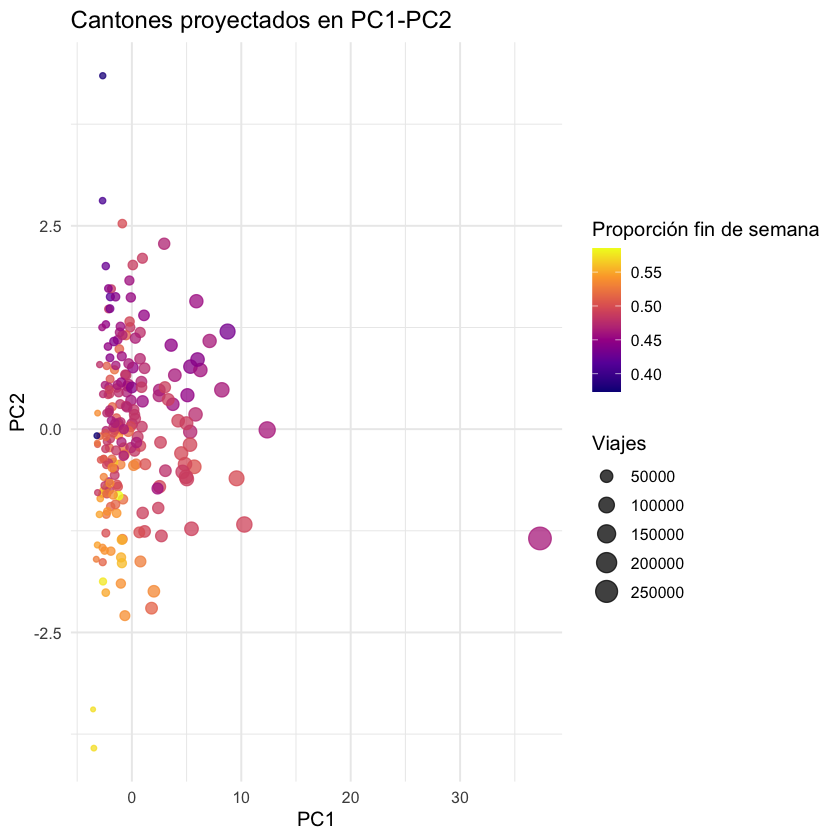

In [24]:
scores_pca <- tidy(pca_roads, matrix = "scores") %>%
  filter(PC <= 4) %>%
  mutate(componente = paste0("PC", PC)) %>%
  select(row, componente, value) %>%
  pivot_wider(names_from = componente, values_from = value) %>%
  arrange(row) %>%
  select(-row) %>%
  bind_cols(metadata_roads)

write_csv(scores_pca, file.path(output_dir, "scores_pca_roads.csv"))

scores_pca %>%
  ggplot(aes(x = PC1, y = PC2, color = prop_weekend, size = viajes)) +
  geom_point(alpha = 0.75) +
  scale_color_viridis_c(option = "C") +
  labs(
    x = "PC1",
    y = "PC2",
    color = "Proporción fin de semana",
    size = "Viajes",
    title = "Cantones proyectados en PC1-PC2"
  )

## 3.2 Cargas de las componentes

Las cargas indican qué variables aportan más a cada componente. Valores altos en magnitud ayudan a interpretar qué representa PC1 o PC2.

In [25]:
cargas_pca <- tidy(pca_roads, matrix = "loadings") %>%
  filter(PC <= 3) %>%
  transmute(
    variable = column,
    componente = paste0("PC", PC),
    carga = value
  ) %>%
  mutate(abs_carga = abs(carga))

write_csv(cargas_pca, file.path(output_dir, "cargas_pca_roads.csv"))

cargas_pca %>%
  group_by(componente) %>%
  slice_max(abs_carga, n = 8, with_ties = FALSE) %>%
  ungroup() %>%
  arrange(componente, desc(abs_carga))

variable,componente,carga,abs_carga
<chr>,<chr>,<dbl>,<dbl>
saturday,PC1,0.25868468,0.25868468
weekday_morning,PC1,0.25856281,0.25856281
friday,PC1,0.25839444,0.25839444
monday,PC1,0.25829474,0.25829474
weekday_afternoon,PC1,0.25826796,0.25826796
tuesday,PC1,0.25762836,0.25762836
weekday_evening,PC1,0.25751623,0.25751623
weekend_morning,PC1,0.25746937,0.25746937
prop_night,PC2,0.72257362,0.72257362


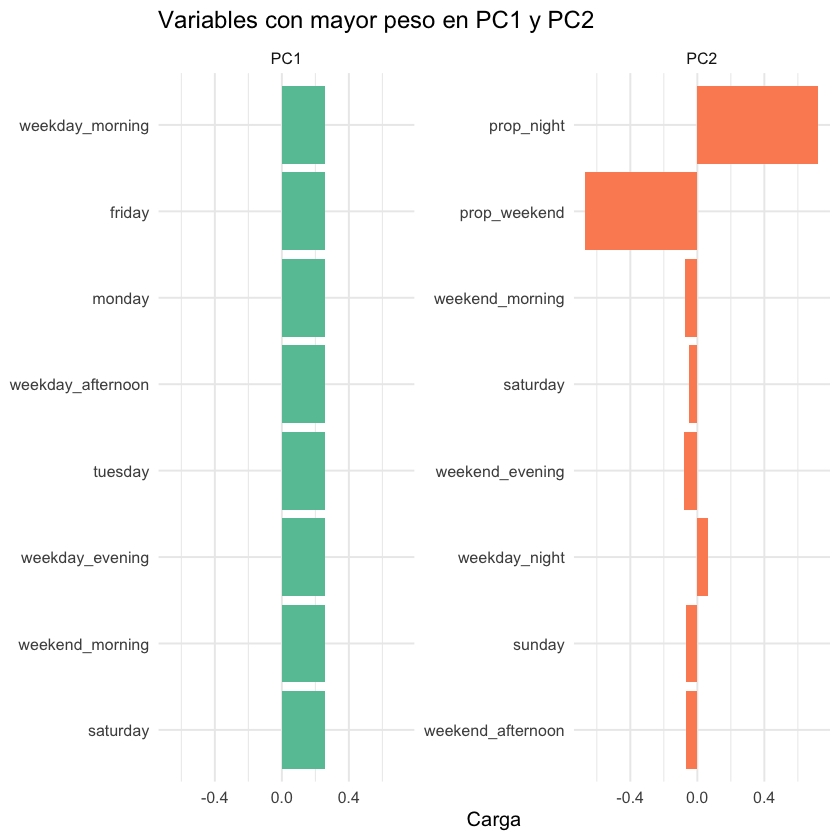

In [26]:
cargas_pca %>%
  filter(componente %in% c("PC1", "PC2")) %>%
  group_by(componente) %>%
  slice_max(abs_carga, n = 8, with_ties = FALSE) %>%
  ungroup() %>%
  ggplot(aes(x = reorder(variable, abs_carga), y = carga, fill = componente)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ componente, scales = "free_y") +
  coord_flip() +
  scale_fill_brewer(palette = "Set2") +
  labs(
    x = NULL,
    y = "Carga",
    title = "Variables con mayor peso en PC1 y PC2"
  )

## 4. k-means sobre componentes principales

Para clustering usaremos componentes principales dentro de la receta del workflow. Esto es importante para evitar fuga de información: durante validación cruzada, el PCA debe aprenderse solo con la parte de entrenamiento de cada fold, no con todos los datos.

In [27]:
# Definimos los datos y la receta que aprende el PCA dentro del workflow de clustering.
umbral_varianza <- 0.90

datos_cluster <- roads %>%
  select(
    monday, tuesday, wednesday, thursday, friday, saturday, sunday,
    weekday_morning, weekday_afternoon, weekday_evening, weekday_night,
    weekend_morning, weekend_afternoon, weekend_evening, weekend_night,
    prop_weekend, prop_night
  )

receta_cluster <- recipe(~ ., data = datos_cluster) %>%
  step_impute_mean(all_numeric_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors()) %>%
  step_pca(all_numeric(), threshold = umbral_varianza, id = "pca_cluster") # Clave para no utilizar PCA como X

# Solo para inspección descriptiva: el workflow volverá a preparar esta receta dentro de cada fold.
prep_cluster_info <- prep(receta_cluster)
x_pca_cluster <- bake(prep_cluster_info, new_data = datos_cluster)
n_componentes <- x_pca_cluster %>% select(starts_with("PC")) %>% ncol()

list(
  umbral_varianza = umbral_varianza,
  n_componentes = n_componentes,
  columnas_cluster = ncol(datos_cluster)
)

$umbral_varianza
[1] 0.9

$n_componentes
[1] 2

$columnas_cluster
[1] 17

## 4.1 Tuning de k con tidyclust

En clustering no hay una variable objetivo externa como en aprendizaje supervisado. Siguiendo el flujo de `tidyclust`, probamos varios valores de `num_clusters` y miramos métricas internas como `sse_ratio`, que compara la variación dentro de clusters contra la variación total.

La métrica no decide por sí sola: buscamos un codo y verificamos que los clusters resultantes sean interpretables.

In [28]:
# Probamos varios valores de k usando validación cruzada con PCA estimado dentro de cada fold.
set.seed(semilla_global)
folds_cluster <- vfold_cv(datos_cluster, v = 5)

modelo_kmeans <- k_means(num_clusters = tune()) %>%
  set_engine("stats")

wf_kmeans <- workflow() %>%
  add_recipe(receta_cluster) %>%
  add_model(modelo_kmeans)

grid_k <- tibble(num_clusters = 2:8)

res_kmeans <- tune_cluster(
  wf_kmeans,
  resamples = folds_cluster,
  grid = grid_k,
  control = control_grid(save_pred = TRUE, extract = identity),
  metrics = cluster_metric_set(sse_within_total, sse_total, sse_ratio)
)

resultados_k <- collect_metrics(res_kmeans)

write_csv(resultados_k, file.path(output_dir, "evaluacion_kmeans_roads.csv"))

resultados_k

num_clusters,.metric,.estimator,mean,n,std_err,.config
<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
2,sse_ratio,standard,0.4845370,5,0.07438285,pre0_mod1_post0
2,sse_total,standard,871.1550782,5,486.22218809,pre0_mod1_post0
2,sse_within_total,standard,511.2185123,5,353.00636618,pre0_mod1_post0
3,sse_ratio,standard,0.3873082,5,0.06099764,pre0_mod2_post0
3,sse_total,standard,871.1550782,5,486.22218809,pre0_mod2_post0
3,sse_within_total,standard,451.7668886,5,326.48162656,pre0_mod2_post0
4,sse_ratio,standard,0.3544976,5,0.06705229,pre0_mod3_post0
4,sse_total,standard,871.1550782,5,486.22218809,pre0_mod3_post0
4,sse_within_total,standard,427.0445585,5,318.49178577,pre0_mod3_post0


## 4.2 Elección exploratoria de k

`sse_ratio` siempre tiende a bajar al aumentar `k`, por lo que no buscamos simplemente el mínimo. La lectura práctica es buscar un codo: un punto a partir del cual agregar más clusters mejora poco la compactación interna.

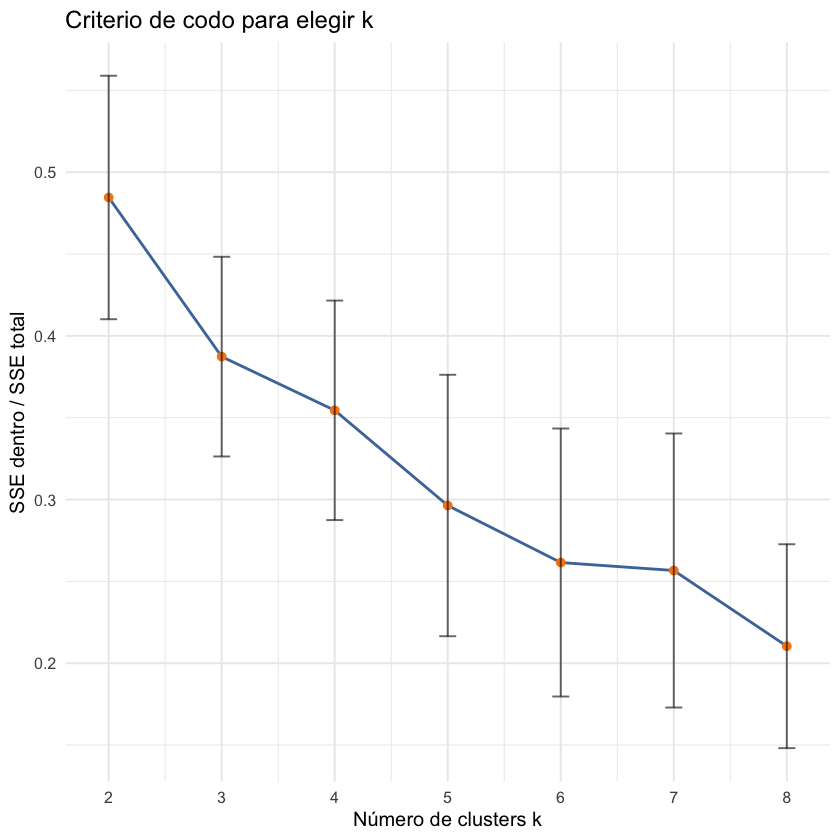

In [29]:
# Graficamos la métrica de compactación para buscar visualmente un posible codo.
resultados_k %>%
  filter(.metric == "sse_ratio") %>%
  ggplot(aes(x = num_clusters, y = mean)) +
  geom_line(linewidth = 0.8, color = "#4C78A8") +
  geom_point(size = 2, color = "#F58518") +
  geom_errorbar(aes(ymin = mean - std_err, ymax = mean + std_err), width = 0.15, alpha = 0.6) +
  scale_x_continuous(breaks = 2:8) +
  labs(
    x = "Número de clusters k",
    y = "SSE dentro / SSE total",
    title = "Criterio de codo para elegir k"
  )

In [30]:
# Ordenamos las métricas internas para comparar cada valor candidato de k.
resultados_k %>%
  filter(.metric %in% c("sse_within_total", "sse_total", "sse_ratio")) %>%
  select(num_clusters, .metric, mean, std_err) %>%
  arrange(.metric, num_clusters)

num_clusters,.metric,mean,std_err
<int>,<chr>,<dbl>,<dbl>
2,sse_ratio,0.4845370,0.07438285
3,sse_ratio,0.3873082,0.06099764
4,sse_ratio,0.3544976,0.06705229
5,sse_ratio,0.2963496,0.07987178
6,sse_ratio,0.2615132,0.08187294
7,sse_ratio,0.2566449,0.08371692
8,sse_ratio,0.2103990,0.06228765
2,sse_total,871.1550782,486.22218809
3,sse_total,871.1550782,486.22218809


## 4.3 Ajuste final de k-means

Elegimos automáticamente el primer `k` donde la mejora relativa de `sse_ratio` frente al valor anterior cae por debajo de 50%. En clase, el estudiante debería revisar el gráfico y discutir si esa elección también es interpretable.

In [31]:
# Seleccionamos un k candidato, ajustamos el modelo final y asignamos cluster a cada cantón.
mejora_k <- resultados_k %>%
  filter(.metric == "sse_ratio") %>%
  arrange(num_clusters) %>%
  mutate(
    mejora_relativa = (dplyr::lag(mean) - mean) / dplyr::lag(mean),
    mejora_relativa = replace_na(mejora_relativa, Inf)
  )

# Introducir mejora relativa
umbral<-0.50
k_candidato <- mejora_k %>%
  filter(num_clusters > min(num_clusters), mejora_relativa < umbral) %>% 
  slice(1) %>%
  pull(num_clusters)

if (length(k_candidato) == 0) {
  k_candidato <- mejora_k %>%
    slice_min(mean, n = 1, with_ties = FALSE) %>%
    pull(num_clusters)
}

final_kmeans <- finalize_workflow(wf_kmeans, tibble(num_clusters = k_candidato))

set.seed(semilla_global)
fit_kmeans_final <- fit(final_kmeans, data = datos_cluster)

scores_cluster <- extract_recipe(fit_kmeans_final, estimated = TRUE) %>%
  bake(new_data = datos_cluster) %>%
  bind_cols(metadata_roads)

clusters_roads <- scores_cluster %>%
  bind_cols(predict(fit_kmeans_final, new_data = datos_cluster)) %>%
  mutate(cluster = factor(.pred_cluster)) %>%
  select(-.pred_cluster)

write_csv(clusters_roads, file.path(output_dir, "clusters_roads.csv"))

clusters_roads %>%
  count(cluster) %>%
  mutate(prop = n / sum(n))


cluster,n,prop
<fct>,<int>,<dbl>
Cluster_1,169,0.808612440
Cluster_2,39,0.186602871
Cluster_3,1,0.004784689


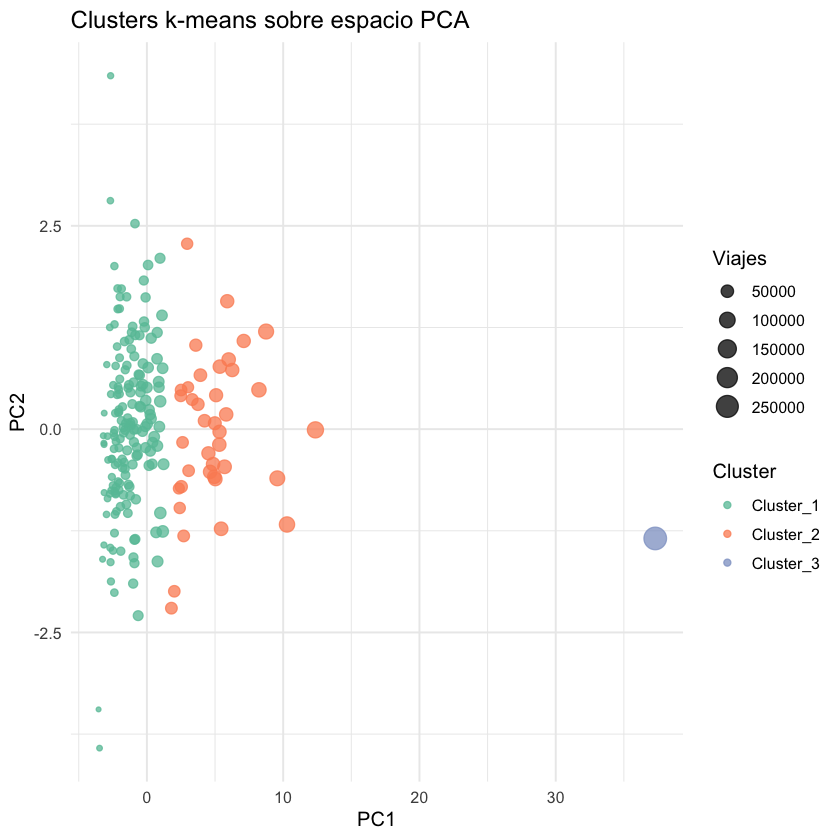

In [32]:
# Visualizamos los clusters en el espacio PCA disponible para interpretar separación o solapamiento.
if ("PC2" %in% names(clusters_roads)) {
  clusters_roads %>%
    ggplot(aes(x = PC1, y = PC2, color = cluster, size = viajes)) +
    geom_point(alpha = 0.75) +
    scale_color_brewer(palette = "Set2") +
    labs(
      x = "PC1",
      y = "PC2",
      color = "Cluster",
      size = "Viajes",
      title = "Clusters k-means sobre espacio PCA"
    )
} else {
  clusters_roads %>%
    ggplot(aes(x = PC1, y = cluster, color = cluster, size = viajes)) +
    geom_jitter(height = 0.12, alpha = 0.75) +
    scale_color_brewer(palette = "Set2") +
    labs(
      x = "PC1",
      y = "Cluster",
      color = "Cluster",
      size = "Viajes",
      title = "Clusters k-means sobre PC1"
    )
}

## 5. Perfil de clusters

El clustering no usa provincia ni nombre del cantón, pero podemos cruzar clusters con esas variables y con indicadores originales para interpretar perfiles de movilidad.

In [33]:
perfil_clusters <- clusters_roads %>%
  group_by(cluster) %>%
  summarise(
    n = n(),
    viajes_promedio = mean(viajes, na.rm = TRUE),
    viajeros_promedio = mean(viajeros, na.rm = TRUE),
    prop_weekend_promedio = mean(prop_weekend, na.rm = TRUE),
    prop_night_promedio = mean(prop_night, na.rm = TRUE),
    provincias = n_distinct(provincia),
    .groups = "drop"
  ) %>%
  arrange(desc(viajes_promedio))

write_csv(perfil_clusters, file.path(output_dir, "perfil_clusters_roads.csv"))

perfil_clusters

cluster,n,viajes_promedio,viajeros_promedio,prop_weekend_promedio,prop_night_promedio,provincias
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Cluster_3,1,270356.29,269056.67,0.4623728,0.08183064,1
Cluster_2,39,56640.40,55848.44,0.4772920,0.06490757,12
Cluster_1,169,13054.38,12863.55,0.4930897,0.06130618,24


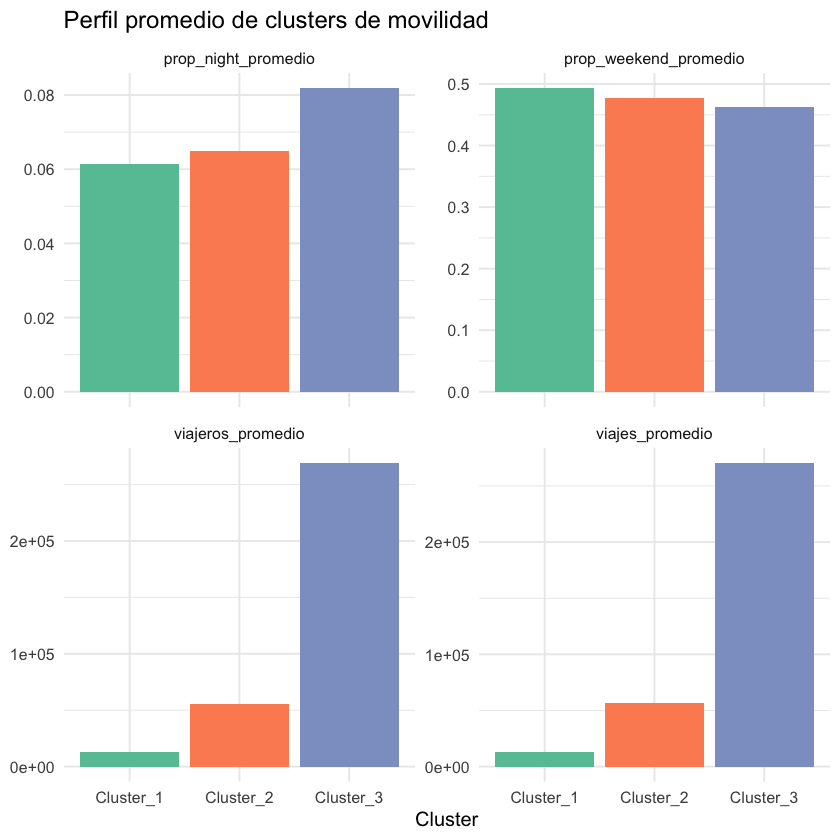

In [34]:
perfil_clusters %>%
  pivot_longer(
    cols = c(viajes_promedio, viajeros_promedio, prop_weekend_promedio, prop_night_promedio),
    names_to = "variable",
    values_to = "valor"
  ) %>%
  ggplot(aes(x = cluster, y = valor, fill = cluster)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ variable, scales = "free_y") +
  scale_fill_brewer(palette = "Set2") +
  labs(
    x = "Cluster",
    y = NULL,
    title = "Perfil promedio de clusters de movilidad"
  )

## 6. Cómo leer los resultados

Preguntas para discusión:

- ¿Los clusters separan cantones por volumen total, por patrón temporal o por ambos?
- ¿Hay clusters con mayor peso relativo de movilidad de fin de semana?
- ¿Hay clusters con mayor movilidad nocturna?
- ¿La separación en el espacio PCA es clara o hay solapamiento?
- ¿El `k` sugerido por `sse_ratio` produce perfiles interpretables para política pública?

## 7. Resumen del flujo completo de ML

El curso siguió un flujo común de trabajo:

1. **Comprender el problema:** definir objetivo, unidad de análisis y variable de interés.
2. **Preparar datos:** imputación, transformación de categorías, normalización cuando corresponde.
3. **Particionar:** separar train/test y usar validación cruzada para selección.
4. **Construir workflows:** encapsular receta + modelo.
5. **Ajustar hiperparámetros:** `tune_grid()` o `tune_bayes()`.
6. **Evaluar:** usar métricas adecuadas para clasificación, regresión o exploración.
7. **Seleccionar modelo candidato:** balancear desempeño, estabilidad e interpretabilidad.
8. **Evaluar en test:** usar `last_fit()` una sola vez en aprendizaje supervisado.
9. **Interpretar y comunicar:** traducir métricas a decisiones sustantivas.

En aprendizaje no supervisado, como PCA y clustering, en general no hay una etiqueta objetivo para optimizar, salvo que se utilicen los factores como predictores. La evaluación combina criterios numéricos, visualización e interpretabilidad.

## 8. Trabajo aplicado con datos INEC

Repetir el flujo exploratorio con `data_pobreza_INEC.xlsx` para segmentar cantones a partir de indicadores socioeconómicos y de acceso a servicios:

- Construir una matriz numérica de indicadores cantonales.
- Excluir `canton` y variables usadas solo para interpretación.
- Usar PCA dentro de la receta para evitar fuga de información.
- Aplicar k-means para varios valores de `k`.
- Evaluar `k` con métricas internas de `tidyclust`, como `sse_ratio`.
- Perfilar clusters usando `canton`, `nbi` e indicadores originales.

La tarea no es “encontrar el cluster correcto”, sino construir una segmentación interpretable y útil para discusión.

In [35]:
# Base alternativa para que el trabajo aplicado no repita los datos de movilidad.
data_inec <- suppressMessages(read_excel("data/data_pobreza_INEC.xlsx"))

inec_cluster <- data_inec %>%
  transmute(
    canton = Canton,
    nbi = NBIMEF,
    internet_inst = PorcentajeInstConInternet,
    tef_11_19 = TEF11a19madre,
    cajeros = `CajerosAutomáticosTasapobmay15años`,
    puntos_financieros = `TotPuntosAteFinTasapobmay15años`,
    pib_pc = PIBpercap,
    fecundidad = TasaGlobalFecundmadre,
    participacion_ensenanza = ParticipacionPIBEnseñanza,
    prematuro = Porcentajenacprematuromoderadomujermujermadre,
    agua_potable = aguaPotableViv,
    oficinas = `OficinasTasapobmay15años`
  )

write_csv(inec_cluster, file.path(output_dir, "inec_cluster_modulo4.csv"))

glimpse(inec_cluster)

# Trabajo del estudiante:
# 1) Crear datos_inec_cluster excluyendo canton y, si se desea, nbi para usarlo solo como interpretación.
# 2) Crear una receta con imputación, normalización y step_pca(all_numeric(), threshold = 0.70).
# 3) Repetir k-means, evaluación de k y visualización en el espacio PCA.
# 4) Interpretar los clusters usando canton, nbi e indicadores originales.

Rows: 221
Columns: 12
$ canton                  <chr> "CUENCA", "GIRON", "GUALACEO", "NABON", "PAUTE…
$ nbi                     <dbl> 0.1982807, 0.3311427, 0.4258015, 0.7230655, 0.…
$ internet_inst           <dbl> 68.28, 66.67, 74.47, 61.82, 67.74, 58.33, 100.…
$ tef_11_19               <dbl> 0.03, 0.09, 0.09, 0.10, 0.05, 0.08, 0.02, 0.09…
$ cajeros                 <dbl> 12, 7, 6, 4, 7, 7, 14, 10, 7, 12, 7, 5, 6, 8, …
$ puntos_financieros      <dbl> 50, 56, 42, 35, 48, 38, 57, 61, 45, 88, 35, 51…
$ pib_pc                  <dbl> 6801, 1784, 2771, 1663, 2515, 2261, 1948, 2448…
$ fecundidad              <dbl> 1.36, 1.97, 1.81, 1.52, 1.54, 1.79, 1.07, 1.87…
$ participacion_ensenanza <dbl> 5.12, 8.67, 6.49, 8.49, 6.79, 6.58, 6.77, 5.80…
$ prematuro               <dbl> 7.05, 6.74, 6.77, 5.48, 6.96, 16.95, 11.76, 5.…
$ agua_potable            <dbl> 169525, 2563, 5036, 1029, 3940, 1115, 1094, 45…
$ oficinas                <dbl> 8, 10, 10, 6, 8, 7, 18, 9, 9, 32, 8, 0, 12, 4,…


In [ ]:
system("conda run -n rbase jupyter nbconvert --to html modulo4.ipynb")